<a href="https://colab.research.google.com/github/elthonjakebasalo346-sys/elthon/blob/main/basalo_activity_01AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [189]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [190]:
iris = load_iris()

In [191]:
iris = load_iris()
print(iris.feature_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [192]:
print(iris.target_names)

['setosa' 'versicolor' 'virginica']


In [193]:
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)
df["species"] = iris.target_names[iris.target]
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [194]:
print("Number of rows: ", df.shape[0])
print("Number of columns: ", df.shape[1])

Number of rows:  150
Number of columns:  5


In [195]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [196]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [197]:
print(df["species"].unique())

['setosa' 'versicolor' 'virginica']


In [198]:
print(df["species"].value_counts())

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


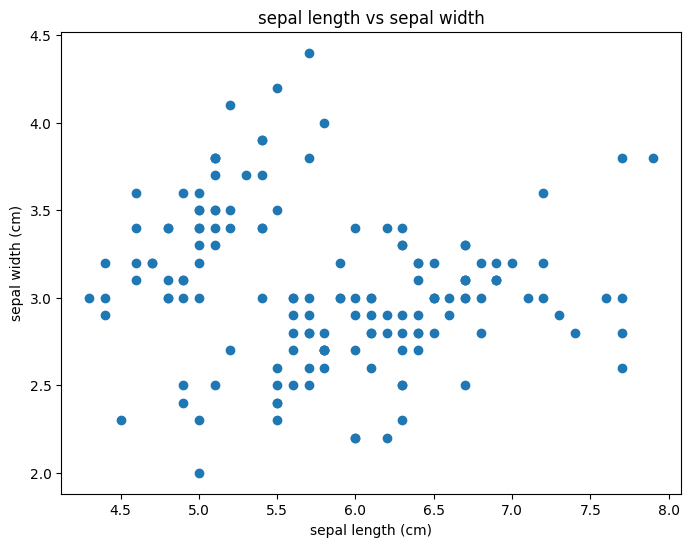

In [199]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["sepal length (cm)"],
    df["sepal width (cm)"]
)
plt.xlabel("sepal length (cm)")
plt.ylabel("sepal width (cm)")
plt.title("sepal length vs sepal width")

plt.show()

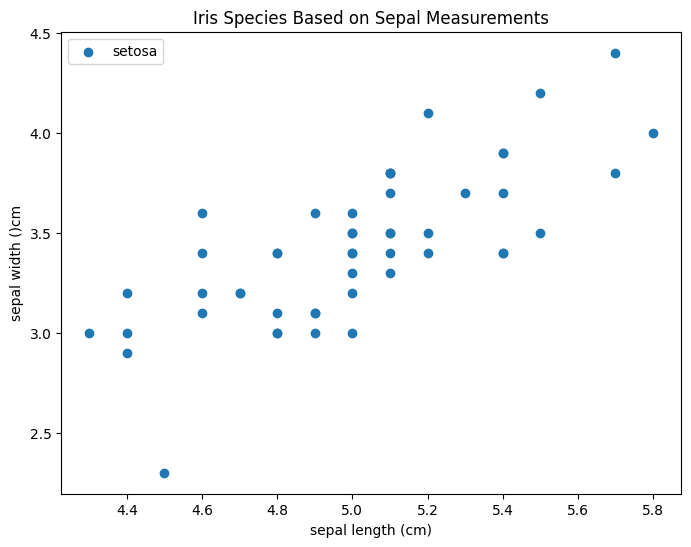

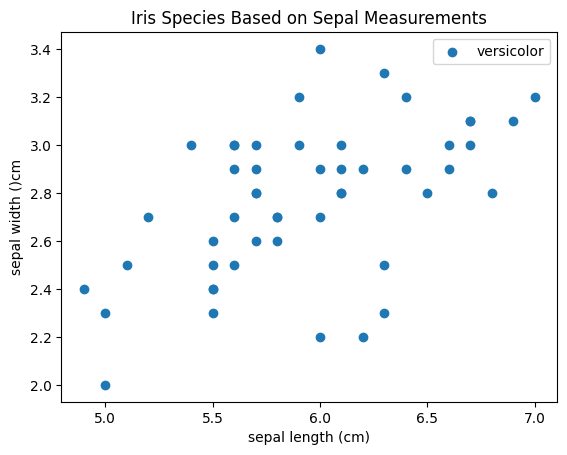

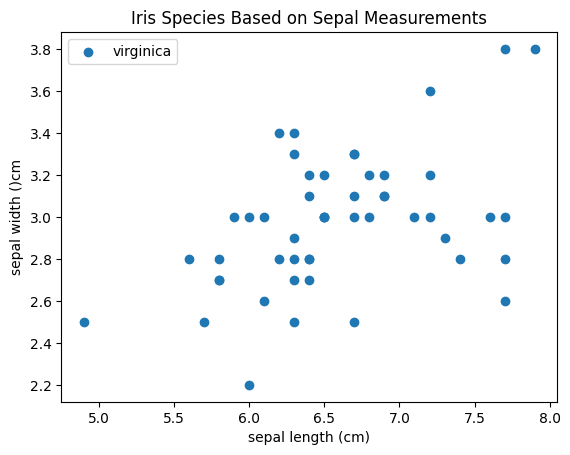

In [200]:
plt.figure(figsize=(8,6))

for species in df["species"].unique():
  subset = df[df["species"]==species]

  plt.scatter(
      subset["sepal length (cm)"],
      subset["sepal width (cm)"],
      label = species
  )

  plt.xlabel("sepal length (cm)")
  plt.ylabel("sepal width ()cm")
  plt.title("Iris Species Based on Sepal Measurements")
  plt.legend()

  plt.show()



In [201]:
x = iris.data
y = iris.target

In [202]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training observations: ", len(x_train))
print("Testing observations: ", len(x_test))

Training observations:  120
Testing observations:  30


In [203]:
model = KNeighborsClassifier(n_neighbors=3)

In [204]:
model.fit(x_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [205]:
y_pred=model.predict(x_test)

In [206]:
print(y_pred)

[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]


In [207]:
print("Actual: ")
print(y_test)

print("\nPredicted: ")
print(y_pred)

Actual: 
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]

Predicted: 
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]


In [208]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: ", accuracy)

Accuracy:  1.0


In [209]:
new_flower = [[5.1, 3.5, 1.4, 0.2]]

In [210]:
prediction=model.predict(new_flower)

In [211]:
print(
    "Prediction: ",
    iris.target_names[prediction[0]]
)

Prediction:  setosa


In [212]:
probabilities = model.predict_proba(new_flower)
print(probabilities)

[[1. 0. 0.]]


In [213]:
for species, probability in zip(
    iris.target_names,
    probabilities[0]

):
  print(f"{species}: {probability:2%}")



setosa: 100.000000%
versicolor: 0.000000%
virginica: 0.000000%


In [214]:
k_values = [1,3,5,7,9]
accuracies = []

for k in k_values:
  model = KNeighborsClassifier(n_neighbors=k)
  model.fit(x_train, y_train)
  y_pred = model.predict(x_test)
  accuracy = accuracy_score(y_test, y_pred)
  accuracies.append(accuracy)
  print(f"k={k}, Accuracy={accuracy:2f}")

k=1, Accuracy=0.966667
k=3, Accuracy=1.000000
k=5, Accuracy=1.000000
k=7, Accuracy=0.966667
k=9, Accuracy=1.000000


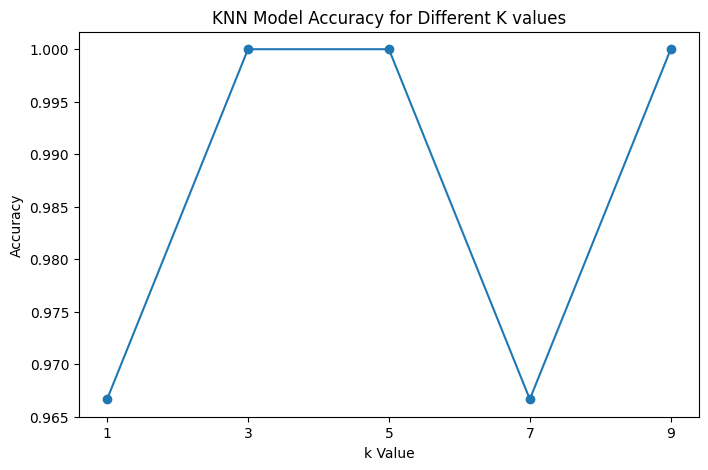

In [216]:
plt.figure(figsize=(8,5))
plt.plot(
    k_values,
    accuracies,
    marker="o"
)

plt.xlabel("k Value")
plt.ylabel("Accuracy")
plt.title("KNN Model Accuracy for Different K values")

plt.xticks(k_values)
plt.show()

In [217]:
results = pd.DataFrame({
    "Actual":iris.target_names[y_test],
    "Predicted":iris.target_names[y_pred]
})

results.head(10)

,Actual,Predicted
0,setosa,setosa
1,virginica,virginica
2,versicolor,versicolor
3,versicolor,versicolor
4,setosa,setosa
5,versicolor,versicolor
6,setosa,setosa
7,setosa,setosa
8,virginica,virginica
9,versicolor,versicolor


In [218]:
results["Correct"] = (
    results["Actual"] == results["Predicted"]
)

results.head(10)

,Actual,Predicted,Correct
0,setosa,setosa,True
1,virginica,virginica,True
2,versicolor,versicolor,True
3,versicolor,versicolor,True
4,setosa,setosa,True
5,versicolor,versicolor,True
6,setosa,setosa,True
7,setosa,setosa,True
8,virginica,virginica,True
9,versicolor,versicolor,True
